Business Understanding
        ↓
Data Collection
        ↓
Dataset Understanding
        ↓
Data Cleaning
        ↓
Handle Missing Values
        ↓
Handle Outliers (if required)
        ↓
Exploratory Data Analysis (EDA)
        ↓
Feature Engineering (if required)
        ↓
Define Features (X) and Target (y)
        ↓
Train-Validation-Test Split
        ↓
Encoding
        ↓
Feature Scaling
        ↓
Convert to Tensors
        ↓
Create Dataset & DataLoader
        ↓
Design Neural Network Architecture
        ↓
Train the Model
        ↓
Evaluate the Model
        ↓
Save Model & Artifacts

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


# Data Collection

In [5]:
from google.colab import files

print("Upload your dataset file(s):")
uploaded = files.upload()

print("Uploaded files:")
for filename in uploaded.keys():
    print(f'- {filename}')

Upload your dataset file(s):


Saving medical_insurance.csv to medical_insurance.csv
Uploaded files:
- medical_insurance.csv


In [3]:
df = pd.read_csv(r"C:\Users\shobh\Downloads\AI and DATA SCIENCE\𝗗𝗲𝗲𝗽 𝗟𝗲𝗮𝗿𝗻𝗶𝗻𝗴 𝗣𝗿𝗼𝗷𝗲𝗰𝘁𝘀\ANN Projects\Medical Insurance Cost Predictor ANN\data\medical_insurance_cost.csv")
pd.set_option("display.max_columns", None)
df.sample(3)

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,bmi,smoker,alcohol_freq,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,systolic_bp,diastolic_bp,ldl,hba1c,plan_type,network_tier,deductible,copay,policy_term_years,policy_changes_last_2yrs,provider_quality,risk_score,annual_medical_cost,annual_premium,monthly_premium,claims_count,avg_claim_amount,total_claims_paid,chronic_count,hypertension,diabetes,asthma,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
67510,44189,56,Male,Central,Urban,31700.0,HS,Single,Unemployed,1,0,21.6,Never,Occasional,1,0,0,3,145.0,103.0,85.0,6.00,POS,Gold,5000,10,1,0,3.13,0.6154,1234.46,427.76,35.65,0,0.00,0.00,1,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,1
90272,82228,84,Male,East,Suburban,18800.0,No HS,Single,Employed,2,1,27.2,Former,NaN,1,0,0,3,158.0,92.0,137.2,5.46,PPO,Gold,500,50,1,0,4.36,1.0000,21856.93,3352.40,279.37,2,6488.47,12976.94,3,1,0,0,0,0,0,0,0,1,1,3,0,1,1,1,1,0
59236,4535,59,Male,East,Urban,27800.0,Doctorate,Widowed,Employed,1,0,35.3,Never,Occasional,1,0,0,1,136.0,86.0,168.9,5.61,HMO,Bronze,5000,20,3,0,3.96,0.7363,5166.11,745.95,62.16,2,1657.00,3314.00,1,1,0,0,0,0,0,0,0,0,0,0,1,0,2,0,1,1


# Dataset Understanding

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  object 
 3   region                       100000 non-null  object 
 4   urban_rural                  100000 non-null  object 
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  object 
 7   marital_status               100000 non-null  object 
 8   employment_status            100000 non-null  object 
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  object 
 13  

In [5]:
df.describe()

,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,systolic_bp,diastolic_bp,ldl,hba1c,deductible,copay,policy_term_years,policy_changes_last_2yrs,provider_quality,risk_score,annual_medical_cost,annual_premium,monthly_premium,claims_count,avg_claim_amount,total_claims_paid,chronic_count,hypertension,diabetes,asthma,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,50000.500000,47.521500,4.987390e+04,2.430900,0.898380,26.990512,1.92765,0.093640,0.373350,1.236320,117.808970,73.604770,119.975065,5.605968,1226.725000,19.520400,5.517760,0.050690,3.598920,0.519849,3009.451907,582.320040,48.526668,1.62178,656.512084,1377.878827,0.724720,0.203450,0.085930,0.058870,0.035950,0.051170,0.021510,0.014620,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,4.680021e+04,1.075126,0.950654,4.994883,1.73773,0.304848,1.373011,1.209358,15.369187,8.900924,30.262086,0.845996,1019.619375,10.286255,2.868827,0.224591,0.594052,0.250669,3127.462822,399.583722,33.298640,2.02982,1072.660048,2305.464687,0.805523,0.402566,0.280262,0.235382,0.186166,0.220345,0.145078,0.120027,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,1.100000e+03,1.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,61.000000,40.000000,30.000000,3.540000,500.000000,10.000000,1.000000,0.000000,1.500000,0.000000,55.550000,211.670000,17.640000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,2.110000e+04,2.000000,0.000000,23.600000,1.00000,0.000000,0.000000,0.000000,107.000000,67.000000,99.400000,5.160000,500.000000,10.000000,3.000000,0.000000,3.200000,0.329700,1175.117500,352.070000,29.340000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,3.620000e+04,2.000000,1.000000,27.000000,2.00000,0.000000,0.000000,1.000000,117.000000,73.000000,120.000000,5.440000,1000.000000,20.000000,6.000000,0.000000,3.600000,0.505500,2082.575000,463.585000,38.630000,1.00000,318.015000,642.545000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,6.220000e+04,3.000000,1.000000,30.400000,3.00000,0.000000,0.000000,2.000000,128.000000,79.000000,140.300000,5.760000,2000.000000,30.000000,8.000000,0.000000,4.010000,0.703300,3707.957500,666.697500,55.560000,2.00000,872.215000,1795.522500,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000
max,100000.000000,100.000000,1.061800e+06,9.000000,7.000000,50.400000,25.00000,3.000000,21.000000,11.000000,183.000000,114.000000,248.300000,11.940000,5000.000000,50.000000,10.000000,2.000000,5.000000,1.000000,65724.9000

In [6]:
df.isnull().sum()

person_id                          0
age                                0
sex                                0
region                             0
urban_rural                        0
income                             0
education                          0
marital_status                     0
employment_status                  0
household_size                     0
dependents                         0
bmi                                0
smoker                             0
alcohol_freq                   30083
visits_last_year                   0
hospitalizations_last_3yrs         0
days_hospitalized_last_3yrs        0
medication_count                   0
systolic_bp                        0
diastolic_bp                       0
ldl                                0
hba1c                              0
plan_type                          0
network_tier                       0
deductible                         0
copay                              0
policy_term_years                  0
p

<h2 style="font-size:30px; color:#1E3A8A; border-bottom:2px solid #DBEAFE; padding-bottom:7px;">
    <strong>Dataset Column Descriptions</strong>
</h2>

<h3 style="color:#1D4ED8;">Demographic & Personal Information</h3>

<div style="background:linear-gradient(135deg,#EFF6FF,#F5F3FF); border-left:5px solid #2563EB; padding:14px 18px; border-radius:8px; line-height:1.9;">

<strong>person_id:</strong> Unique identifier assigned to each person in the dataset. Not used as a predictive feature.<br><br>
<strong>age:</strong> Age of the person in years.<br><br>
<strong>sex:</strong> Sex category of the person.<br><br>
<strong>region:</strong> Geographic region where the person is located.<br><br>
<strong>urban_rural:</strong> Classification of the person's residential area.<br><br>
<strong>income:</strong> Approximate annual income of the person.<br><br>
<strong>education:</strong> Highest education level attained by the person.<br><br>
<strong>marital_status:</strong> Marital status of the person.<br><br>
<strong>employment_status:</strong> Employment category of the person.<br><br>
<strong>household_size:</strong> Total number of people living in the person's household.<br><br>
<strong>dependents:</strong> Number of dependents associated with the person.

</div>

<h3 style="color:#15803D;">Health & Lifestyle Information</h3>

<div style="background:linear-gradient(135deg,#F0FDF4,#ECFDF5); border-left:5px solid #16A34A; padding:14px 18px; border-radius:8px; line-height:1.9;">

<strong>bmi:</strong> Body Mass Index of the person.<br><br>
<strong>smoker:</strong> Whether the person is a smoker.<br><br>
<strong>alcohol_freq:</strong> Frequency of alcohol consumption. Has a lot of missing values, dropped later.<br><br>
<strong>visits_last_year:</strong> Number of healthcare visits in the previous year.<br><br>
<strong>hospitalizations_last_3yrs:</strong> Number of hospitalizations in the previous three years.<br><br>
<strong>days_hospitalized_last_3yrs:</strong> Total days hospitalized in the previous three years.<br><br>
<strong>medication_count:</strong> Number of medications currently associated with the person.

</div>

<h3 style="color:#991B1B;">Clinical Measurements</h3>

<div style="background:linear-gradient(135deg,#FEF2F2,#FFF1F2); border-left:5px solid #DC2626; padding:14px 18px; border-radius:8px; line-height:1.9;">

<strong>systolic_bp:</strong> Systolic blood pressure.<br><br>
<strong>diastolic_bp:</strong> Diastolic blood pressure.<br><br>
<strong>ldl:</strong> LDL cholesterol level.<br><br>
<strong>hba1c:</strong> Average blood glucose level over 2-3 months.

</div>

<h3 style="color:#7E22CE;">Insurance Policy Information</h3>

<div style="background:linear-gradient(135deg,#FAF5FF,#F5F3FF); border-left:5px solid #9333EA; padding:14px 18px; border-radius:8px; line-height:1.9;">

<strong>plan_type:</strong> Type of insurance plan.<br><br>
<strong>network_tier:</strong> Tier of the healthcare provider network.<br><br>
<strong>deductible:</strong> Amount paid before coverage begins.<br><br>
<strong>copay:</strong> Fixed amount paid for a covered service.<br><br>
<strong>policy_term_years:</strong> Duration of the policy in years.<br><br>
<strong>policy_changes_last_2yrs:</strong> Number of policy changes in the previous two years.<br><br>
<strong>provider_quality:</strong> Score representing quality of the healthcare provider/network.<br><br>
<strong>risk_score:</strong> Estimated healthcare risk score. Dropped later, this leaks target information.

</div>

<h3 style="color:#A16207;">Medical Cost & Insurance Financial Information</h3>

<div style="background:linear-gradient(135deg,#FEFCE8,#FFFBEB); border-left:5px solid #EAB308; padding:14px 18px; border-radius:8px; line-height:1.9;">

<strong>annual_medical_cost:</strong> Total medical/healthcare expenditure over a year. <strong>This is the target variable.</strong><br><br>
<strong>annual_premium, monthly_premium, claims_count, avg_claim_amount, total_claims_paid:</strong> All dropped later since they are directly derived from the same billing process as the target and would leak information.

</div>

<h3 style="color:#0F766E;">Chronic Medical Conditions</h3>

<div style="background:linear-gradient(135deg,#F0FDFA,#ECFEFF); border-left:5px solid #0D9488; padding:14px 18px; border-radius:8px; line-height:1.9;">

<strong>chronic_count:</strong> Total number of chronic medical conditions.<br><br>
<strong>hypertension, diabetes, asthma, copd, cardiovascular_disease, cancer_history, kidney_disease, liver_disease, arthritis, mental_health:</strong> Binary indicators (1 = present, 0 = absent).

</div>

<h3 style="color:#C2410C;">Medical Procedure Information</h3>

<div style="background:linear-gradient(135deg,#FFF7ED,#FFEDD5); border-left:5px solid #F97316; padding:14px 18px; border-radius:8px; line-height:1.9;">

<strong>proc_imaging_count, proc_surgery_count, proc_physio_count, proc_consult_count, proc_lab_count:</strong> Counts of different medical procedures.<br><br>
<strong>is_high_risk:</strong> Dropped later, derived from risk_score.<br><br>
<strong>had_major_procedure:</strong> Dropped later, directly tied to the procedure counts and cost.

</div>

# Data Cleaning

In [7]:
# alcohol_freq has a lot of missing values, dropping the column instead of imputing

print("alcohol_freq missing %:", df["alcohol_freq"].isnull().mean() * 100)

df.drop(columns=["alcohol_freq"], inplace=True)

alcohol_freq missing %: 30.083


In [8]:
# columns that should not be used as input features
# person_id is just an identifier
# annual_premium, monthly_premium, claims_count, avg_claim_amount, total_claims_paid, risk_score, is_high_risk, had_major_procedure
# all of these are directly derived from the same billing/claims process as the target, keeping them would leak the answer

unwanted_columns = [
    "person_id",
    "annual_premium",
    "monthly_premium",
    "claims_count",
    "avg_claim_amount",
    "total_claims_paid",
    "risk_score",
    "is_high_risk",
    "had_major_procedure",
]

df.drop(columns=unwanted_columns, inplace=True)

df.shape

(100000, 44)

# Exploratory Data Analysis (EDA)

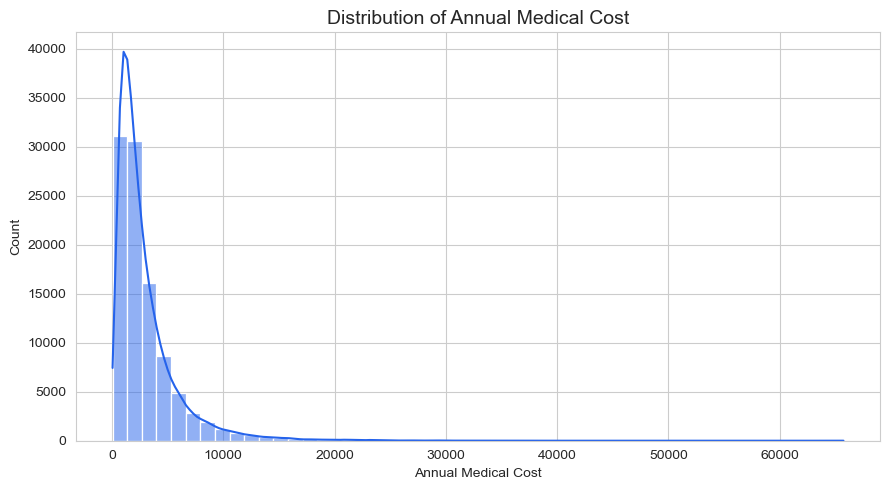

In [9]:
sns.set_style("whitegrid")

plt.figure(figsize=(9, 5))
sns.histplot(df["annual_medical_cost"], kde=True, color="#2563EB", bins=50)
plt.title("Distribution of Annual Medical Cost", fontsize=14)
plt.xlabel("Annual Medical Cost")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../images/01_target_distribution.png")
plt.show()

In [ ]:
numerical_columns = df.select_dtypes(include=["number"]).columns.tolist()
numerical_columns.remove("annual_medical_cost")

fig, axes = plt.subplots(7, 5, figsize=(24, 26))
axes = axes.flatten()

colors = sns.color_palette("husl", len(numerical_columns))

for i, col in enumerate(numerical_columns):
    sns.histplot(df[col], kde=True, ax=axes[i], color=colors[i])
    axes[i].set_title(col, fontsize=10)

for j in range(len(numerical_columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("../images/02_numerical_distributions.png")
plt.show()

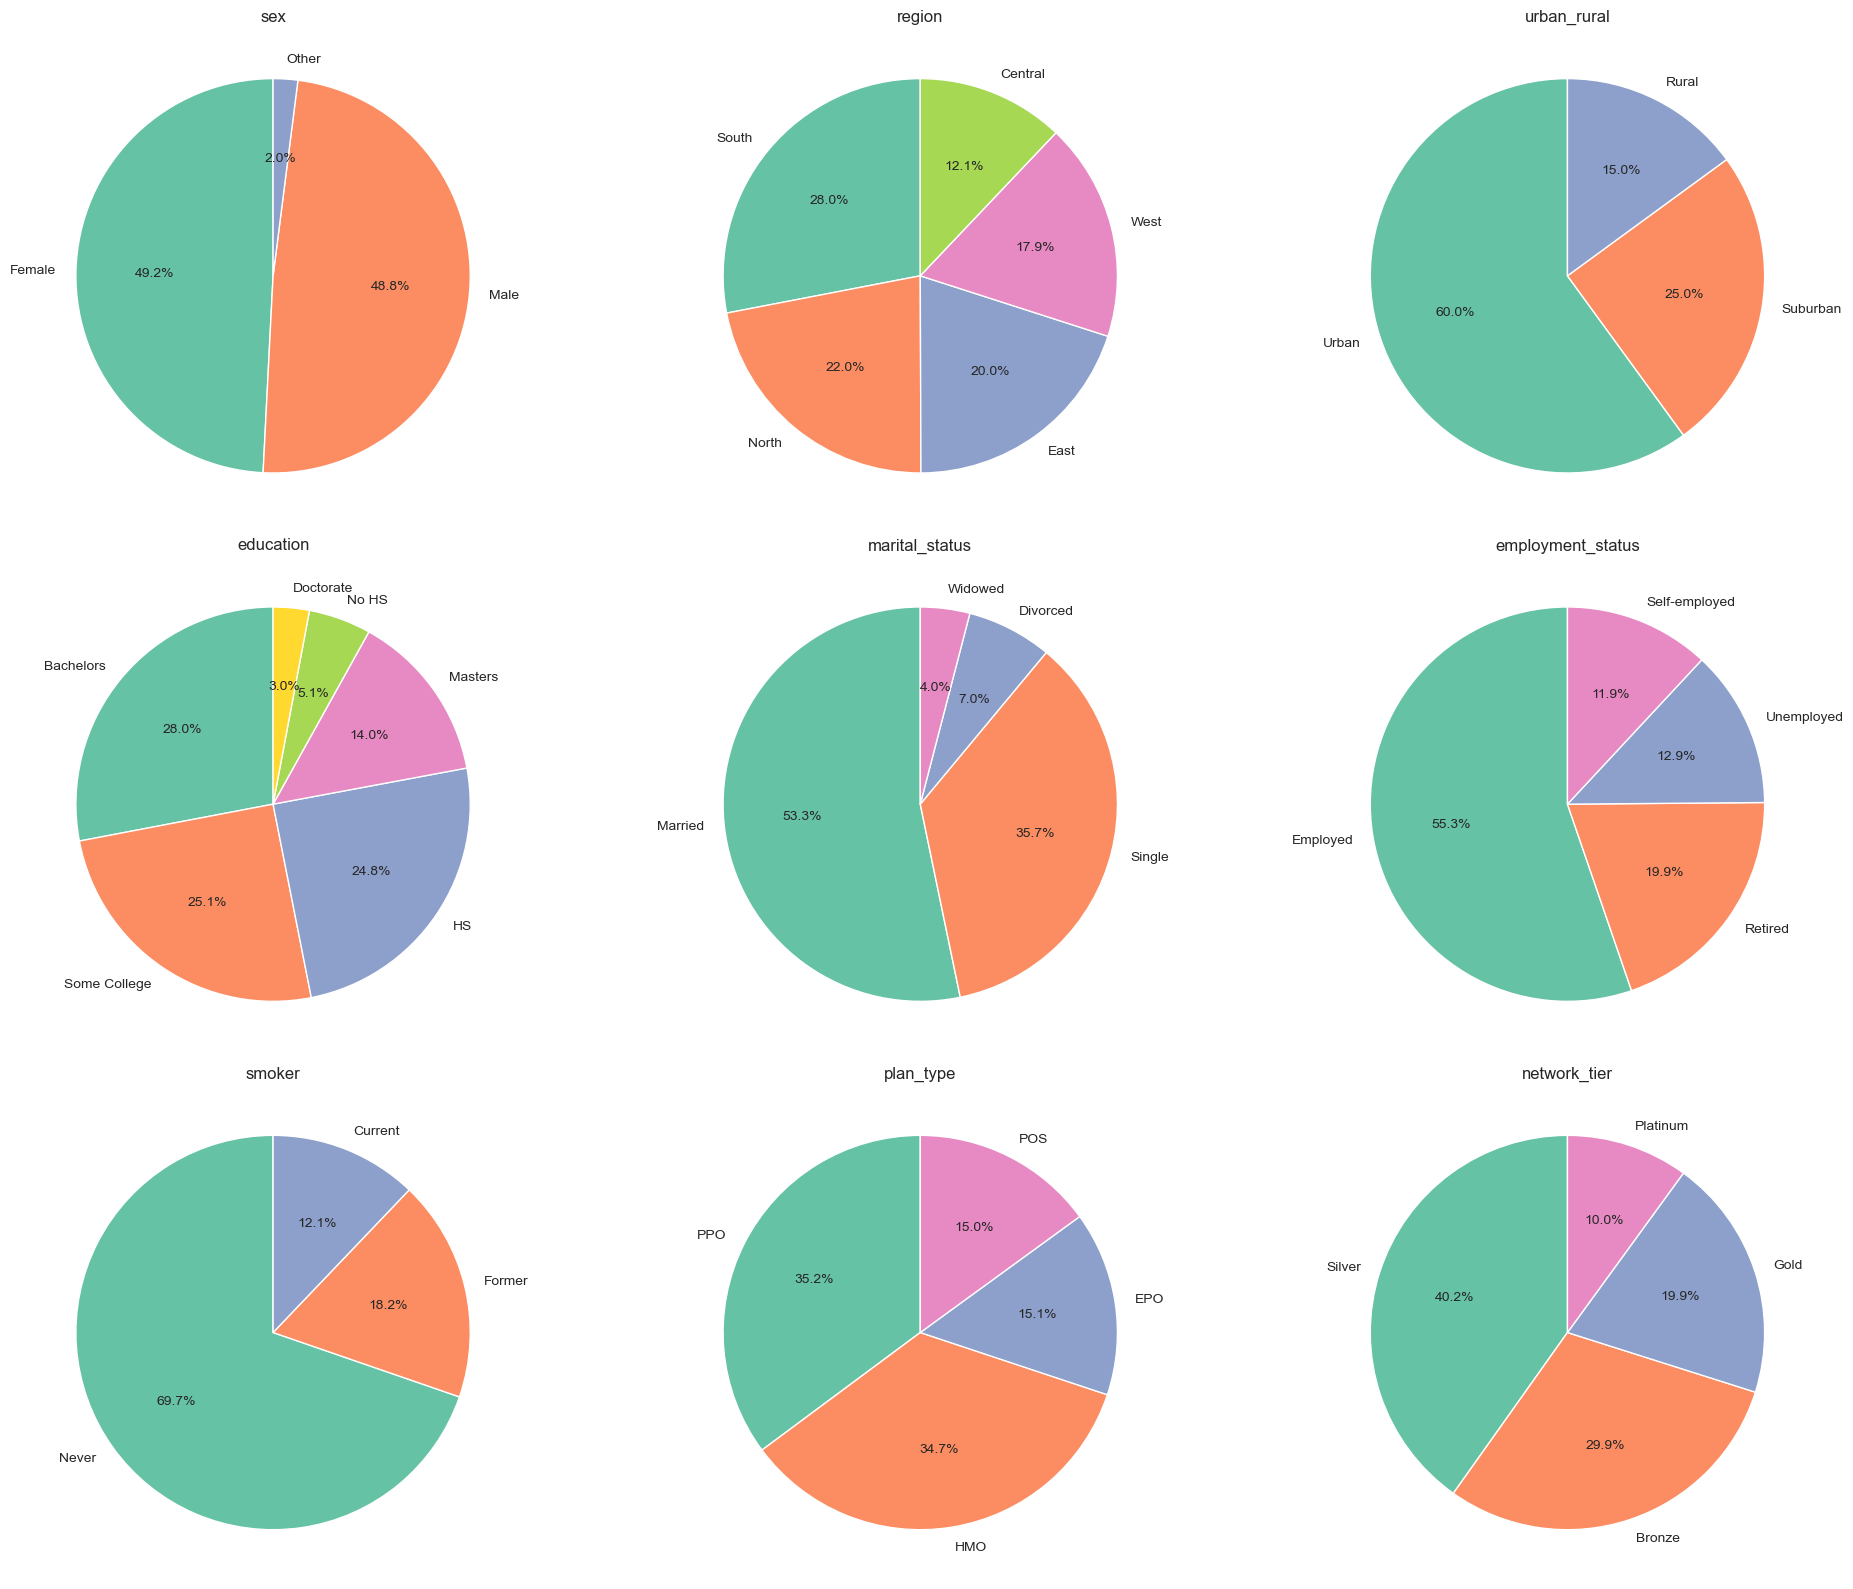

In [11]:
categorical_columns = df.select_dtypes(include="object").columns.tolist()

fig, axes = plt.subplots(3, 3, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(categorical_columns):
    counts = df[col].value_counts()
    axes[i].pie(
        counts.values,
        labels=counts.index,
        autopct="%1.1f%%",
        colors=sns.color_palette("Set2", len(counts)),
        startangle=90,
    )
    axes[i].set_title(col, fontsize=12)

plt.tight_layout()
plt.savefig("../images/03_categorical_distributions.png")
plt.show()

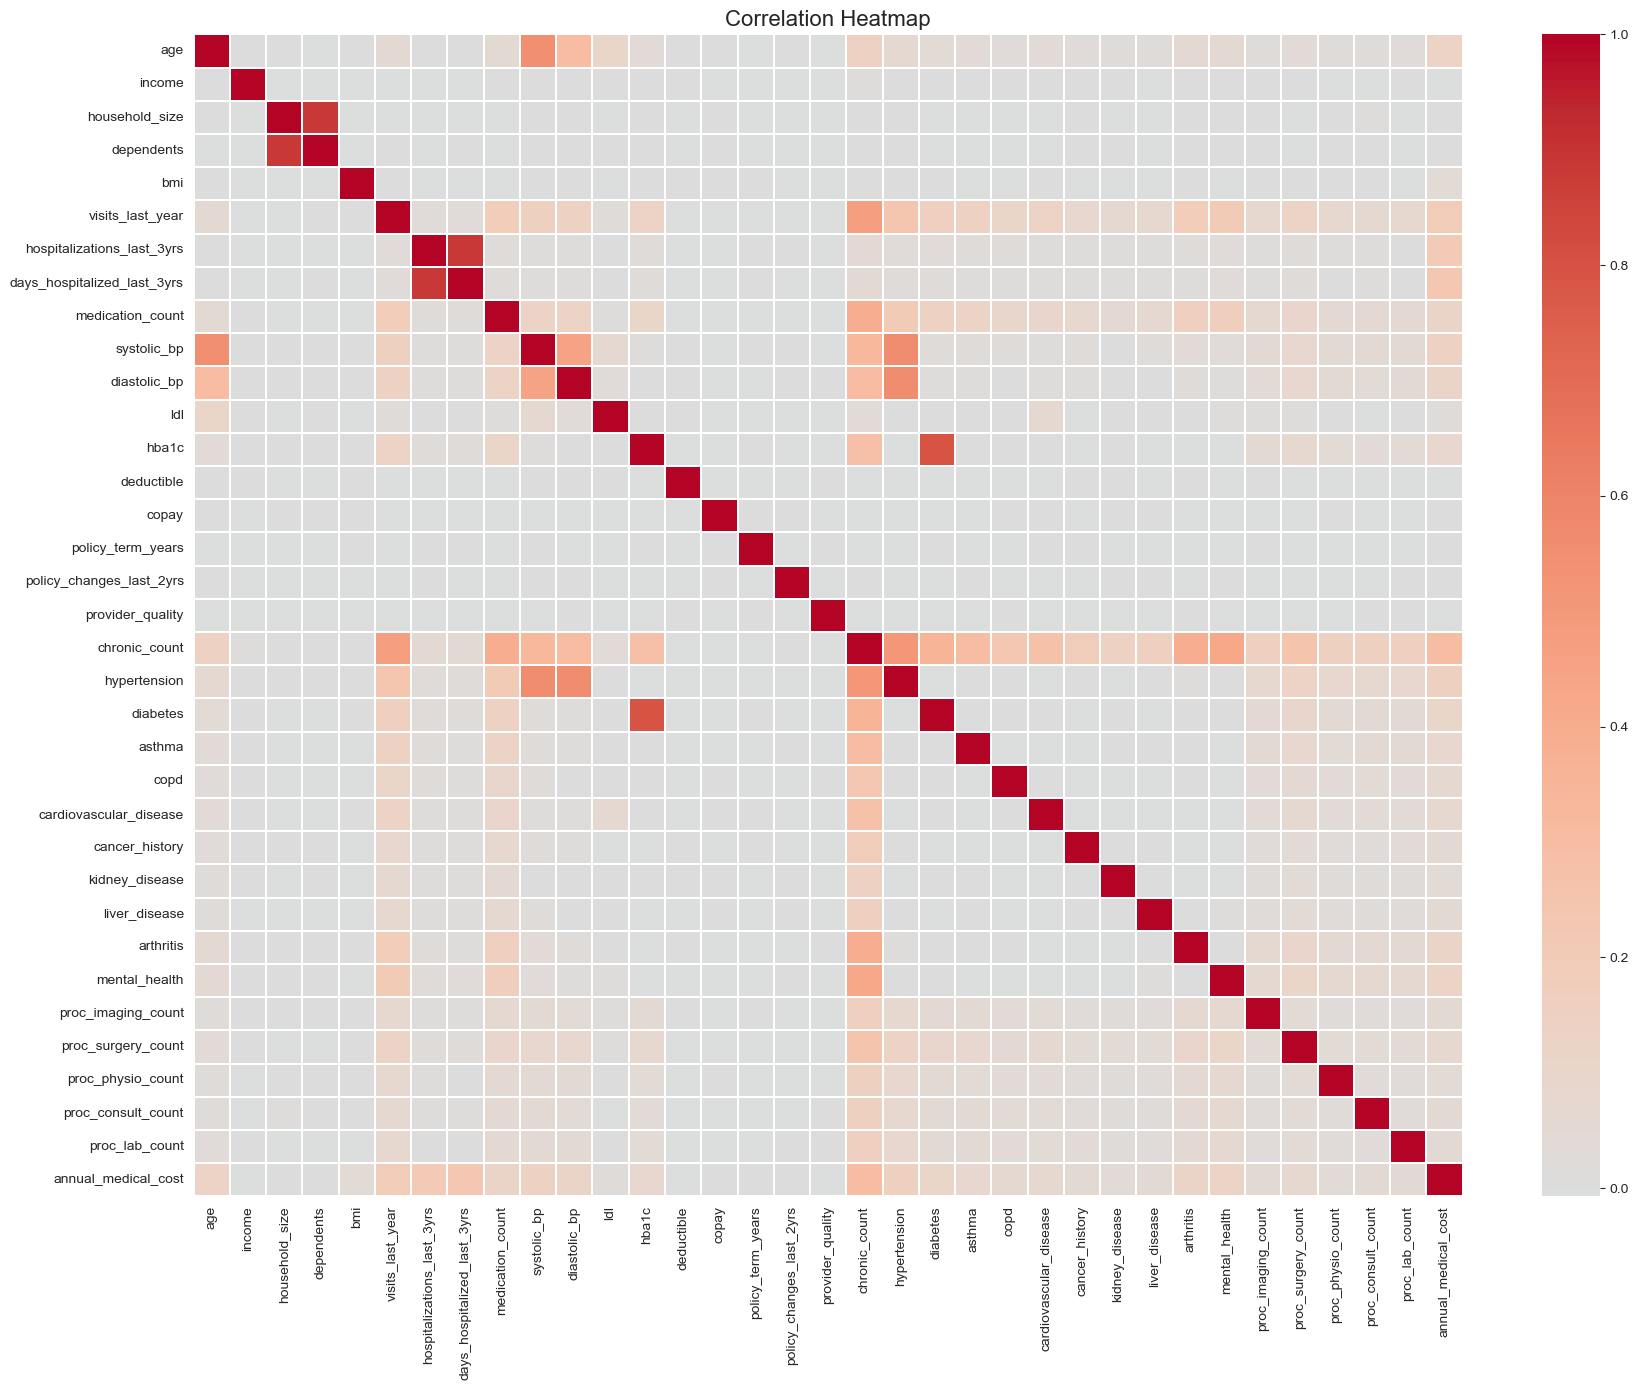

In [12]:
plt.figure(figsize=(18, 14))
corr = df[numerical_columns + ["annual_medical_cost"]].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, linewidths=0.3)
plt.title("Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.savefig("../images/04_correlation_heatmap.png")
plt.show()

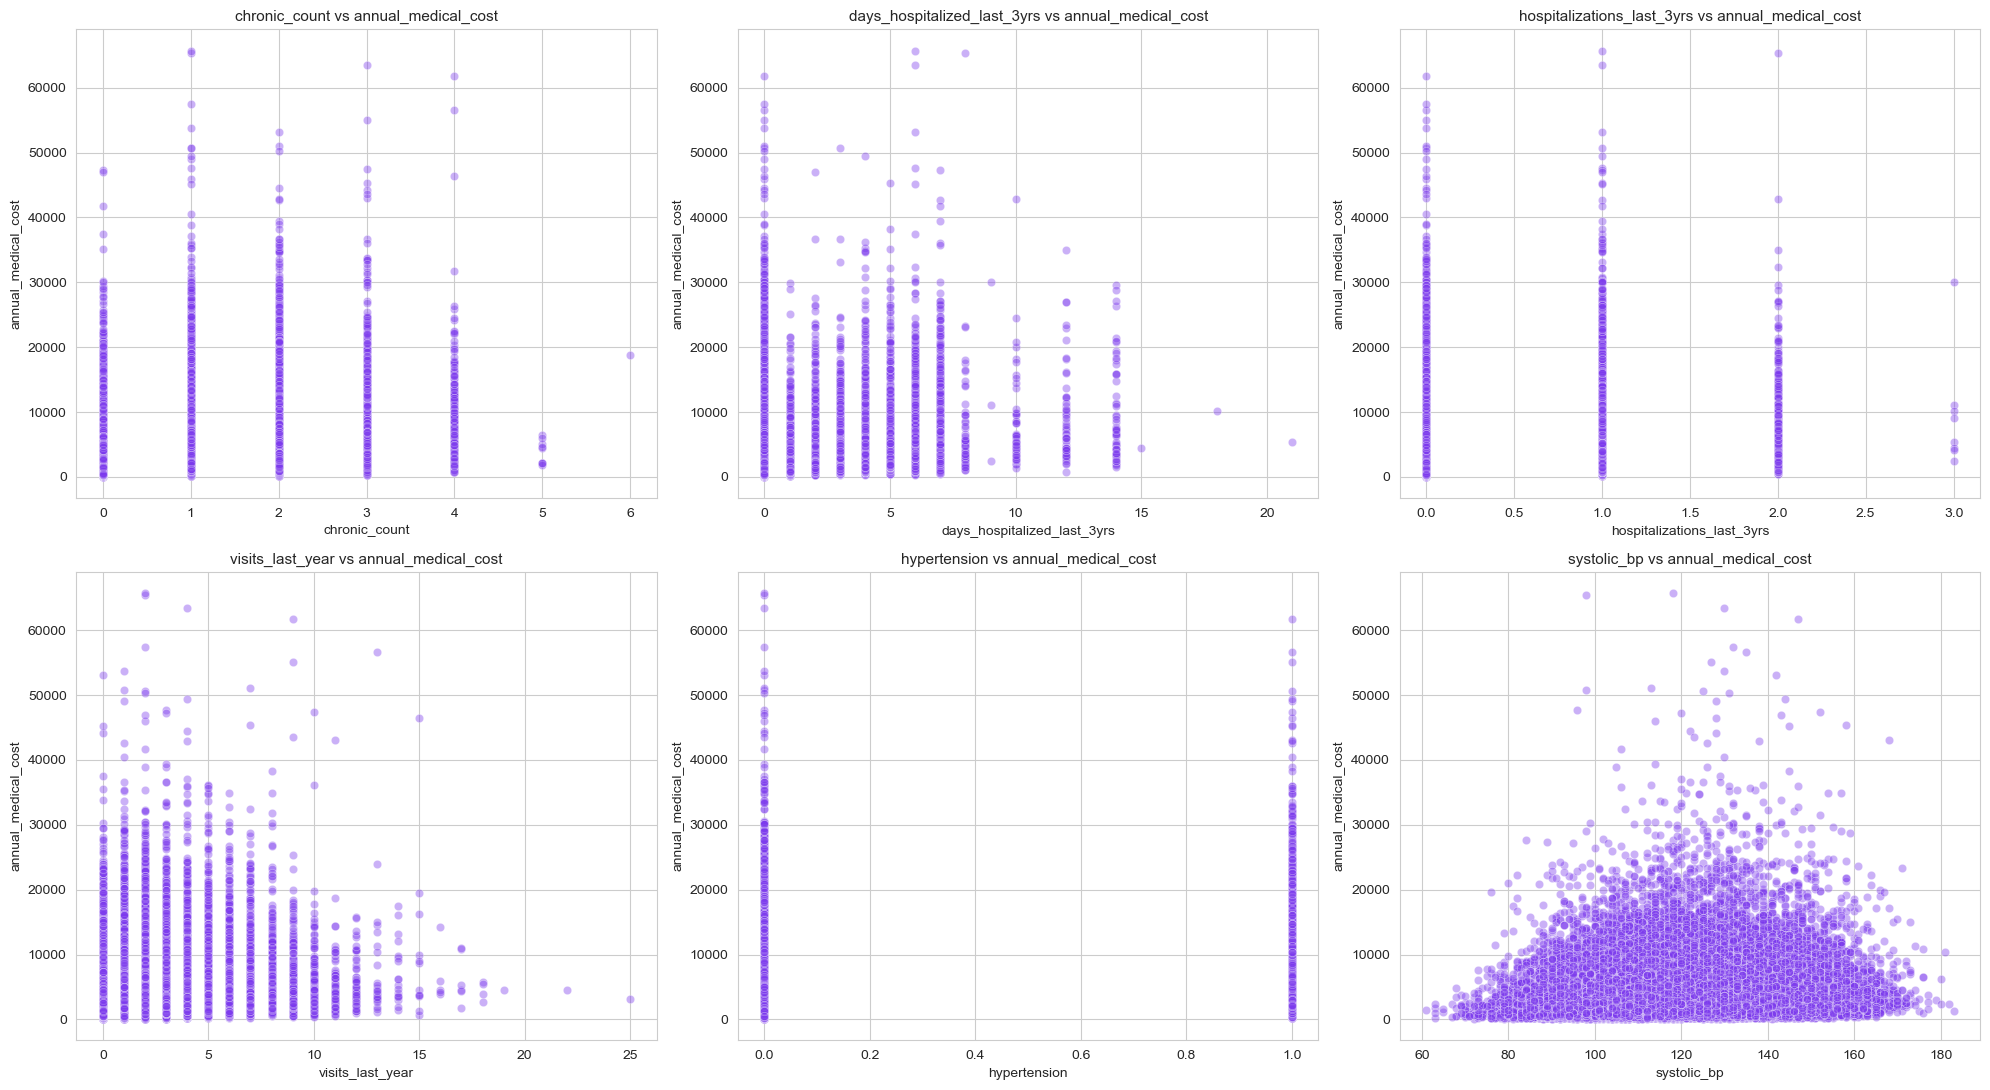

In [13]:
top_corr_features = corr["annual_medical_cost"].abs().sort_values(ascending=False)[1:7].index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes = axes.flatten()

for i, col in enumerate(top_corr_features):
    sns.scatterplot(x=df[col], y=df["annual_medical_cost"], ax=axes[i], color="#7C3AED", alpha=0.4)
    axes[i].set_title(f"{col} vs annual_medical_cost", fontsize=11)

plt.tight_layout()
plt.savefig("../images/05_feature_vs_target.png")
plt.show()

# Define Features (X) and Target (y)

In [17]:
X = df.drop(columns=["annual_medical_cost"])
y = df["annual_medical_cost"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100000, 43)
y shape: (100000,)


# Train-Validation-Test Split

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

In [19]:
print("Training Set   :", X_train.shape)
print("Validation Set :", X_valid.shape)
print("Testing Set    :", X_test.shape)

print()

print("Training Labels   :", y_train.shape)
print("Validation Labels :", y_valid.shape)
print("Testing Labels    :", y_test.shape)

Training Set   : (70000, 43)
Validation Set : (15000, 43)
Testing Set    : (15000, 43)

Training Labels   : (70000,)
Validation Labels : (15000,)
Testing Labels    : (15000,)


# Encoding

In [20]:
categorical_columns = X_train.select_dtypes(include="object").columns.tolist()

print(categorical_columns)
print("\n==========================\n")

numerical_columns = X_train.select_dtypes(include=["number"]).columns.tolist()

numerical_columns

['sex', 'region', 'urban_rural', 'education', 'marital_status', 'employment_status', 'smoker', 'plan_type', 'network_tier']




['age',
 'income',
 'household_size',
 'dependents',
 'bmi',
 'visits_last_year',
 'hospitalizations_last_3yrs',
 'days_hospitalized_last_3yrs',
 'medication_count',
 'systolic_bp',
 'diastolic_bp',
 'ldl',
 'hba1c',
 'deductible',
 'copay',
 'policy_term_years',
 'policy_changes_last_2yrs',
 'provider_quality',
 'chronic_count',
 'hypertension',
 'diabetes',
 'asthma',
 'copd',
 'cardiovascular_disease',
 'cancer_history',
 'kidney_disease',
 'liver_disease',
 'arthritis',
 'mental_health',
 'proc_imaging_count',
 'proc_surgery_count',
 'proc_physio_count',
 'proc_consult_count',
 'proc_lab_count']

In [21]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_cat = encoder.fit_transform(X_train[categorical_columns])
X_valid_cat = encoder.transform(X_valid[categorical_columns])
X_test_cat = encoder.transform(X_test[categorical_columns])

X_train_cat.shape

(70000, 36)

# Feature Scaling

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[numerical_columns])
X_valid_num = scaler.transform(X_valid[numerical_columns])
X_test_num = scaler.transform(X_test[numerical_columns])

X_train_num.shape

(70000, 34)

In [23]:
X_train_final = np.hstack([X_train_num, X_train_cat])
X_valid_final = np.hstack([X_valid_num, X_valid_cat])
X_test_final = np.hstack([X_test_num, X_test_cat])

encoded_cat_names = encoder.get_feature_names_out(categorical_columns).tolist()
feature_order = numerical_columns + encoded_cat_names

print("Final feature count:", len(feature_order))

Final feature count: 70


# Convert to Tensors

In [24]:
X_train_tensor = torch.tensor(X_train_final, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_valid_tensor = torch.tensor(X_valid_final, dtype=torch.float32).to(device)
y_valid_tensor = torch.tensor(y_valid.values, dtype=torch.float32).view(-1, 1).to(device)

X_test_tensor = torch.tensor(X_test_final, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1).to(device)

# Create Dataset & DataLoader

In [25]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Design Neural Network Architecture

In [26]:
class InsuranceANN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.network(x)

In [27]:
model = InsuranceANN(input_dim=X_train_final.shape[1]).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model

InsuranceANN(
  (network): Sequential(
    (0): Linear(in_features=70, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)

# Train the Model

In [28]:
epochs = 100
train_losses = []
valid_losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    epoch_train_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)

    model.eval()
    with torch.no_grad():
        valid_preds = model(X_valid_tensor)
        epoch_valid_loss = criterion(valid_preds, y_valid_tensor).item()
        valid_losses.append(epoch_valid_loss)

    if (epoch + 1) % 10 == 0:
        print(f"epoch {epoch + 1}/{epochs} - train loss: {epoch_train_loss:.2f} - valid loss: {epoch_valid_loss:.2f}")

epoch 10/100 - train loss: 8045653.70 - valid loss: 8362194.50
epoch 20/100 - train loss: 7973340.78 - valid loss: 8352833.50
epoch 30/100 - train loss: 7961615.36 - valid loss: 8388153.50
epoch 40/100 - train loss: 7953767.82 - valid loss: 8355268.50
epoch 50/100 - train loss: 7941085.63 - valid loss: 8383680.50
epoch 60/100 - train loss: 7904683.31 - valid loss: 8407783.00
epoch 70/100 - train loss: 7884933.82 - valid loss: 8400935.00
epoch 80/100 - train loss: 7848127.49 - valid loss: 8402222.00
epoch 90/100 - train loss: 7849005.09 - valid loss: 8425335.00
epoch 100/100 - train loss: 7822302.01 - valid loss: 8429464.00


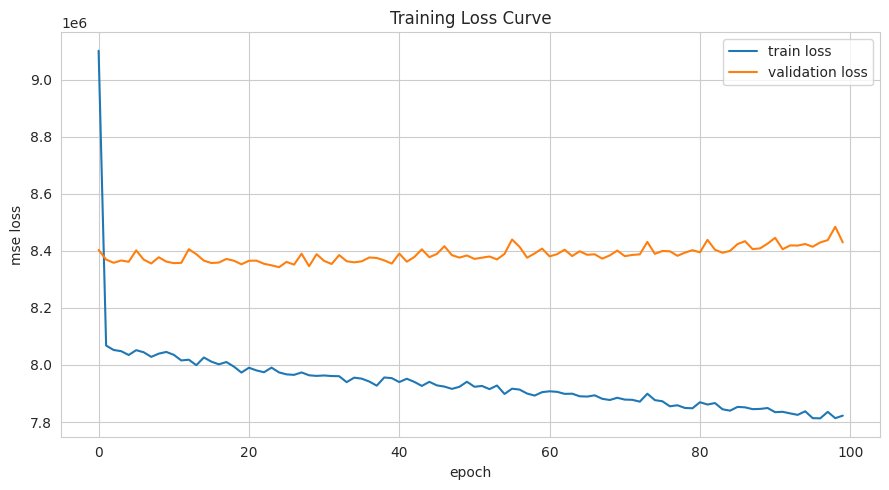

In [29]:
plt.figure(figsize=(9, 5))
plt.plot(train_losses, label="train loss")
plt.plot(valid_losses, label="validation loss")
plt.xlabel("epoch")
plt.ylabel("mse loss")
plt.title("Training Loss Curve")
plt.legend()
plt.tight_layout()
plt.savefig("../images/06_training_loss.png")
plt.show()

# Evaluate the Model

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model.eval()
with torch.no_grad():
    test_preds = model(X_test_tensor).cpu().numpy().flatten()

y_test_actual = y_test.values

mae = mean_absolute_error(y_test_actual, test_preds)
rmse = np.sqrt(mean_squared_error(y_test_actual, test_preds))
r2 = r2_score(y_test_actual, test_preds)

print("Test MAE :", mae)
print("Test RMSE:", rmse)
print("Test R2  :", r2)

Test MAE : 1787.4166332130537
Test RMSE: 2920.6959867726337
Test R2  : 0.16756623261279302


FileNotFoundError: [Errno 2] No such file or directory: '../images/07_actual_vs_predicted.png'

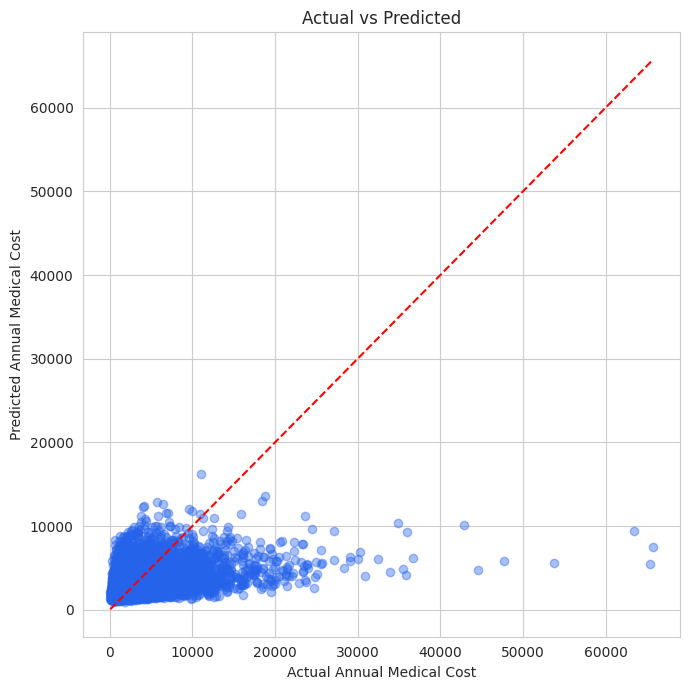

In [31]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test_actual, test_preds, alpha=0.4, color="#2563EB")
plt.plot(
    [y_test_actual.min(), y_test_actual.max()],
    [y_test_actual.min(), y_test_actual.max()],
    color="red",
    linestyle="--"
)
plt.xlabel("Actual Annual Medical Cost")
plt.ylabel("Predicted Annual Medical Cost")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.savefig("../images/07_actual_vs_predicted.png")
plt.show()

In [ ]:
residuals = y_test_actual - test_preds

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(test_preds, residuals, alpha=0.4, color="#16A34A")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted Value")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=50, color="#F97316")
axes[1].set_xlabel("Residual")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.savefig("../images/08_residual_analysis.png")
plt.show()

# Save Model & Artifacts

In [33]:
import os
import pickle
import torch

# Create folders
os.makedirs("/content/models", exist_ok=True)
os.makedirs("/content/artifacts", exist_ok=True)

# Save PyTorch model
torch.save(
    model.state_dict(),
    "/content/models/medical_insurance_ann.pth"
)

# Save encoder
with open("/content/artifacts/encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)

# Save scaler
with open("/content/artifacts/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save feature metadata
feature_meta = {
    "numerical_columns": numerical_columns,
    "categorical_columns": categorical_columns,
    "feature_order": feature_order,
}

with open("/content/artifacts/feature_order.pkl", "wb") as f:
    pickle.dump(feature_meta, f)

print("✅ Model and artifacts saved successfully!")

✅ Model and artifacts saved successfully!
